In [2]:
import numpy as np
import scipy
import jax
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.special import logsumexp as LSE
from matplotlib import pyplot as plt
import pickle as pkl
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=16)

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'

from tqdm import tqdm


ndim = 3

Nobs = 100
true_mean = 0
true_sd = 0.25
noise_dir = 'large_noise'
true_obs = true_sd * jr.normal(jr.PRNGKey(0), shape=(Nobs,ndim)) + true_mean # model is a Gaussian with mean = mu (1, 1, 1, ..., ndim), and same for sigma = sig (1, ..., ndim)
noise = 1
noise_obs = noise * jr.normal(jr.PRNGKey(1), shape=(Nobs,ndim))
obs = true_obs + noise_obs

PRNGkey = jr.PRNGKey(42)

print('ndim = ', ndim)

def calculate_contour(log_p_array, contour=np.array([0.9]), flatten=True):
    if flatten:
        log_p_array = log_p_array.flatten()
    ln_p_sort = -np.sort(-log_p_array) # sort from big to small
    cdf = np.cumsum(np.exp(ln_p_sort))
    cdf /= cdf[-1] # normalize

    p_boundary = np.interp(contour, cdf, ln_p_sort) # pdf boundary between inner and outer contour
    return p_boundary
    
def draw_PE_sample(PRNGkey, NPE, observations, noise_sigma):
    scatter = jax.random.normal(PRNGkey, shape=(observations.shape[0], ndim, NPE)) * noise_sigma
    r = jnp.expand_dims(observations, axis=2) + scatter
    # print(r.shape)
    return r

def log_gaussian(x, mu, sigma):
    p = jnp.sum(-(x - mu)**2 / 2 / sigma**2, axis=1) - ndim*0.5*jnp.log(2*jnp.pi) - jnp.sum(jnp.log(sigma), axis=1)
    # print(p.shape)
    return p

@jax.jit
def naive_log_likelihood_estimator(mu, sigma, observations_array):
    # expand dims to right shapes
    
    # num_dimension = len(jnp.shape(mu))    # assume shapes are same for mu and sigma
    # observations_array = jnp.expand_dims(observations_array, axis=tuple([2+ii for ii in range(num_dimension)]))
    
    obs_weights = log_gaussian(observations_array, mu[None,:,None], sigma[None,:,None])
    NPE = obs_weights.shape[1]

    # runs out of memory, split up computation over mu and sigma subs...
    numerator = LSE(obs_weights, axis=1) - jnp.log(NPE)
    # print(numerator, denominator)

    var_numerator = jnp.exp(LSE(2*obs_weights, axis=1) - 2*jnp.log(NPE) - 2*numerator) - 1/NPE
    num_variance = jnp.sum(var_numerator, axis=0)
    neffs = jnp.exp(2*LSE(obs_weights, axis=1) - LSE(2*obs_weights, axis=1))
    worst_neff = jnp.min(neffs, axis=0)

    return jnp.sum(numerator, axis=0), num_variance, worst_neff

@jax.jit
def numerator_covariance_term(mu, sigma, mup, sigmap, observations_array):

    num_dimension = len(jnp.shape(mu))
    observations_array = jnp.expand_dims(observations_array, axis=tuple([3+ii for ii in range(num_dimension)]))
    
    obs_weights = log_gaussian(observations_array, mu[None,:,None], sigma[None,:,None])
    obs_weights_p = log_gaussian(observations_array, mup[None,:,None], sigmap[None,:,None]) # shape (Nobs, Npe)
    NPE = obs_weights.shape[1]

    numerator = LSE(obs_weights, axis=1) - jnp.log(NPE)
    numerator_p = LSE(obs_weights_p, axis=1) - jnp.log(NPE) 

    cov_numerator = LSE(obs_weights+obs_weights_p, axis=1)-numerator-numerator_p-jnp.log(NPE)-jnp.log(NPE-1)
    cov_numerator = jnp.exp(cov_numerator) - 1 / (NPE-1)
    cov = jnp.sum(cov_numerator, axis=0)

    return cov

def covariance_matrix(mu_samples, sigma_samples, observations, npe):
    '''
    idea is that mu_samples, sigma_samples should be from the biased posterior
    we can derive the correction from this
    '''
    assert mu_samples.shape[0] == sigma_samples.shape[0] # ensure same number of samples each

    f = lambda i,j: numerator_covariance_term(mu_samples[i], sigma_samples[i], 
                        mu_samples[j], sigma_samples[j], observations)
    
    indexes = jnp.arange(mu_samples.shape[0])
    ii, jj = jnp.meshgrid(indexes, indexes)
    cov = jax.tree.map(f, ii, jj) # Nsamples by Nsamples array
    assert (cov == cov.T).all() # ensure symmetric
    return cov

def ez_posterior_bias_correction(mu_samples, sigma_samples, observations, npe, noise_sigma):
    '''
    idea is that mu_samples, sigma_samples should be from the biased posterior
    we can derive the correction from this, this is the simple leading order correction
    '''
    cov = covariance_matrix(mu_samples, sigma_samples, observations, npe)

    weights = jnp.mean(cov, axis=1)
    return weights # we can sample according to a modified likelihood here, where we add this correction to the likelihood
    # after sampling once, and then computing the weight from the OLD BIASED posterior

def advanced_posterior_bias_correction(mu_samples, sigma_samples, observations, npe, noise_sigma):
    '''
    idea is that mu_samples, sigma_samples should be from the biased posterior
    we can derive the correction from this, this is the more advanced correction making assumptions
    about the Gaussianity of the posterior and the linear nature of the deviations from it
    '''
    cov = covariance_matrix(mu_samples, sigma_samples, observations, npe) / jnp.shape(mu_samples)[0] 
    # this is C_ik in the note, need to divide by number of posterior samples
    identity = jnp.diag(cov.shape[0])
    one_plus_cov = identity + cov
    B = jnp.linalg.inv(one_plus_cov)
    # this is a fixed matrix
    assert jnp.allclose(jnp.sum(B[...,None]*one_plus_cov[None,...], axis=1), identity) 
    # check inversion is good, maybe otherwise we need to use jnp.linalg.solve
    meanB = jnp.mean(B, axis=1)

    # below is wrong. 
    '''
    gamma_1 = jnp.mean(jnp.sum(cov[...,None]*B[None,...], axis=1), axis=-1)
    gamma_2 = 0.5 * jnp.sum(cov*(B.T - identity), axis=1)
    gamma = gamma_1 - gamma_2

    return gamma # ok these are WEIGHTS to weight the resultant posterior by, but... these are likely to be crazy?
    # so say we sample once, we get a bunch of posterior samples. Now, 
    '''
    # actually we want to now compute a vector of covariances between some random point in the space, and the posterior samples.
    # TBD tomorrow!

def analytical_likelihood(mu, sigma, observations_centers, noise_sigma):

    Nobs = len(observations_centers)
    log_l_norm = -(Nobs / 2) * jnp.sum(jnp.log(2*jnp.pi*(sigma**2 + noise_sigma**2)))
    expo = -jnp.sum((observations_centers - mu[None,:])**2 / 2 / (sigma[None,:]**2 + noise_sigma**2), axis=(0,1))
    ll = expo + log_l_norm
    return ll

def analytical_posterior(mu, sigma_log, observations_centers, noise_sigma, dsigma):

    ll = analytical_likelihood(mu, jnp.exp(10*sigma_log), observations_centers, noise_sigma)
    log_evidence = LSE(ll) + jnp.log(dsigma)
    log_posterior = ll - log_evidence
    return log_posterior, log_evidence


ndim =  3


In [21]:
import numpyro
from numpyro.infer import MCMC, NUTS
import numpyro.distributions as dist
constraints = dist.constraints

def analytical_model(data=None):
    mus = numpyro.sample('mu', dist.ImproperUniform(constraints.real, (), event_shape=(ndim,)))
    sigmas = numpyro.sample('sigma', dist.ImproperUniform(constraints.positive, (), event_shape=(ndim,)))

    ll = analytical_likelihood(mus, sigmas, data, noise)
    numpyro.factor('log_likelihood', ll)

def numerical_model(data=None):

    mus = numpyro.sample('mu', dist.ImproperUniform(constraints.real, (), event_shape=(ndim,)))
    sigmas = numpyro.sample('sigma', dist.ImproperUniform(constraints.positive, (), event_shape=(ndim,)))

    ll, var, wneff = naive_log_likelihood_estimator(mus, sigmas, data)
    numpyro.deterministic('ll_variance', var)
    numpyro.deterministic('worst_neff', wneff)
    
    numpyro.factor('log_likelihood', ll)

analytical_nuts_kernel = NUTS(analytical_model)
analytical_mcmc = MCMC(analytical_nuts_kernel, num_warmup=1000, num_samples=1000)
analytical_mcmc.run(jr.PRNGKey(1), data=obs)

analytical_mcmc.print_summary()

rhat_thresh = 1.01
neff_thresh = 100

numerical_hierarchical_posterior_samples = []
PRNGkey = jr.PRNGKey(42)

npe = 100
nrandom = 100

summary = []
iterable = tqdm(range(nrandom))
for ii in iterable:

    PRNGkey, _ = jr.split(PRNGkey)
    observations_array = draw_PE_sample(PRNGkey, npe, obs, noise)

    numerical_nuts_kernel = NUTS(numerical_model)
    numerical_mcmc = MCMC(numerical_nuts_kernel, num_warmup=100, num_samples=500, progress_bar=False)
    numerical_mcmc.run(jr.PRNGKey(1), data=observations_array)
    
    samples = numerical_mcmc.get_samples()
    summ = numpyro.diagnostics.summary(samples, group_by_chain=False)
    exceptions = ['ll_variance', 'worst_neff']
    worst_rhat = np.max([summ[key]['r_hat'] for key in summ if key not in exceptions])
    worst_neff = np.min([summ[key]['n_eff'] for key in summ if key not in exceptions])
    if worst_rhat > rhat_thresh:
        print(f'warning: rhat = {worst_rhat} > {rhat_thresh}')
    if worst_neff < neff_thresh:
        print(f'warning: neff = {worst_neff} < {neff_thresh}')
    iterable.set_description(f'Worst Neff = {worst_neff}, Worst Rhat = {worst_rhat}')
    summary.append(summ)
    samples = np.concatenate((samples['mu'], samples['sigma']), axis=1)
    
    numerical_hierarchical_posterior_samples.append(samples)
    
numerical_hierarchical_posterior_samples = np.array(numerical_hierarchical_posterior_samples)
dir_location = f'data/{noise_dir}/Ndim{ndim}_Nobs{Nobs}/'
os.makedirs(dir_location, exist_ok=True)
samples = analytical_mcmc.get_samples()
samples = np.concatenate((samples['mu'], samples['sigma']), axis=1)
with open(dir_location + f'npe_{npe}_nrepeat{nrandom}.pkl', 'wb') as ff:
    pkl.dump({'analytical_samples': samples, 'samples': numerical_hierarchical_posterior_samples, 'meta_data': summary}, ff)

sample: 100%|██████████| 2000/2000 [00:09<00:00, 221.38it/s, 15 steps of size 3.27e-01. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
     mu[0]     -0.02      0.11     -0.02     -0.20      0.14    745.98      1.00
     mu[1]      0.06      0.11      0.06     -0.13      0.22    692.94      1.00
     mu[2]     -0.03      0.11     -0.03     -0.21      0.16    817.37      1.00
  sigma[0]      0.27      0.18      0.25      0.00      0.53    445.56      1.01
  sigma[1]      0.23      0.15      0.22      0.00      0.42    631.72      1.00
  sigma[2]      0.57      0.17      0.58      0.29      0.86    435.77      1.00

Number of divergences: 0


Worst Neff = 256.95266704153664, Worst Rhat = 1.013628363609314:  26%|██▌       | 26/100 [01:38<04:40,  3.78s/it] 

Worst Neff = 240.26083747001599, Worst Rhat = 1.0213299989700317:  32%|███▏      | 32/100 [01:58<03:53,  3.43s/it]

Worst Neff = 239.74864843196818, Worst Rhat = 1.0208780765533447:  34%|███▍      | 34/100 [02:05<03:49,  3.48s/it]

Worst Neff = 344.4024935352234, Worst Rhat = 1.011789321899414:  36%|███▌      | 36/100 [02:12<03:41,  3.45s/it]  

Worst Neff = 297.1231804414912, Worst Rhat = 1.0226002931594849:  65%|██████▌   | 65/100 [04:06<02:21,  4.04s/it] 

Worst Neff = 509.53026607640595, Worst Rhat = 1.0014777183532715: 100%|██████████| 100/100 [06:18<00:00,  3.78s/it]


In [2]:
dir_location = f'data/{noise_dir}/Ndim{ndim}_Nobs{Nobs}/'
os.makedirs(dir_location, exist_ok=True)
npe = 100
nrandom = 100
with open(dir_location + f'npe_{npe}_nrepeat{nrandom}.pkl', 'rb') as ff:
    dictionary = pkl.load(ff)
    analytical_samples = dictionary['analytical_samples']
    numerical_hierarchical_posterior_samples = dictionary['samples']
    

/home/jack.heinzel/.conda/envs/gwjax311/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
100%|██████████| 100/100 [06:15<00:00,  3.75s/it]


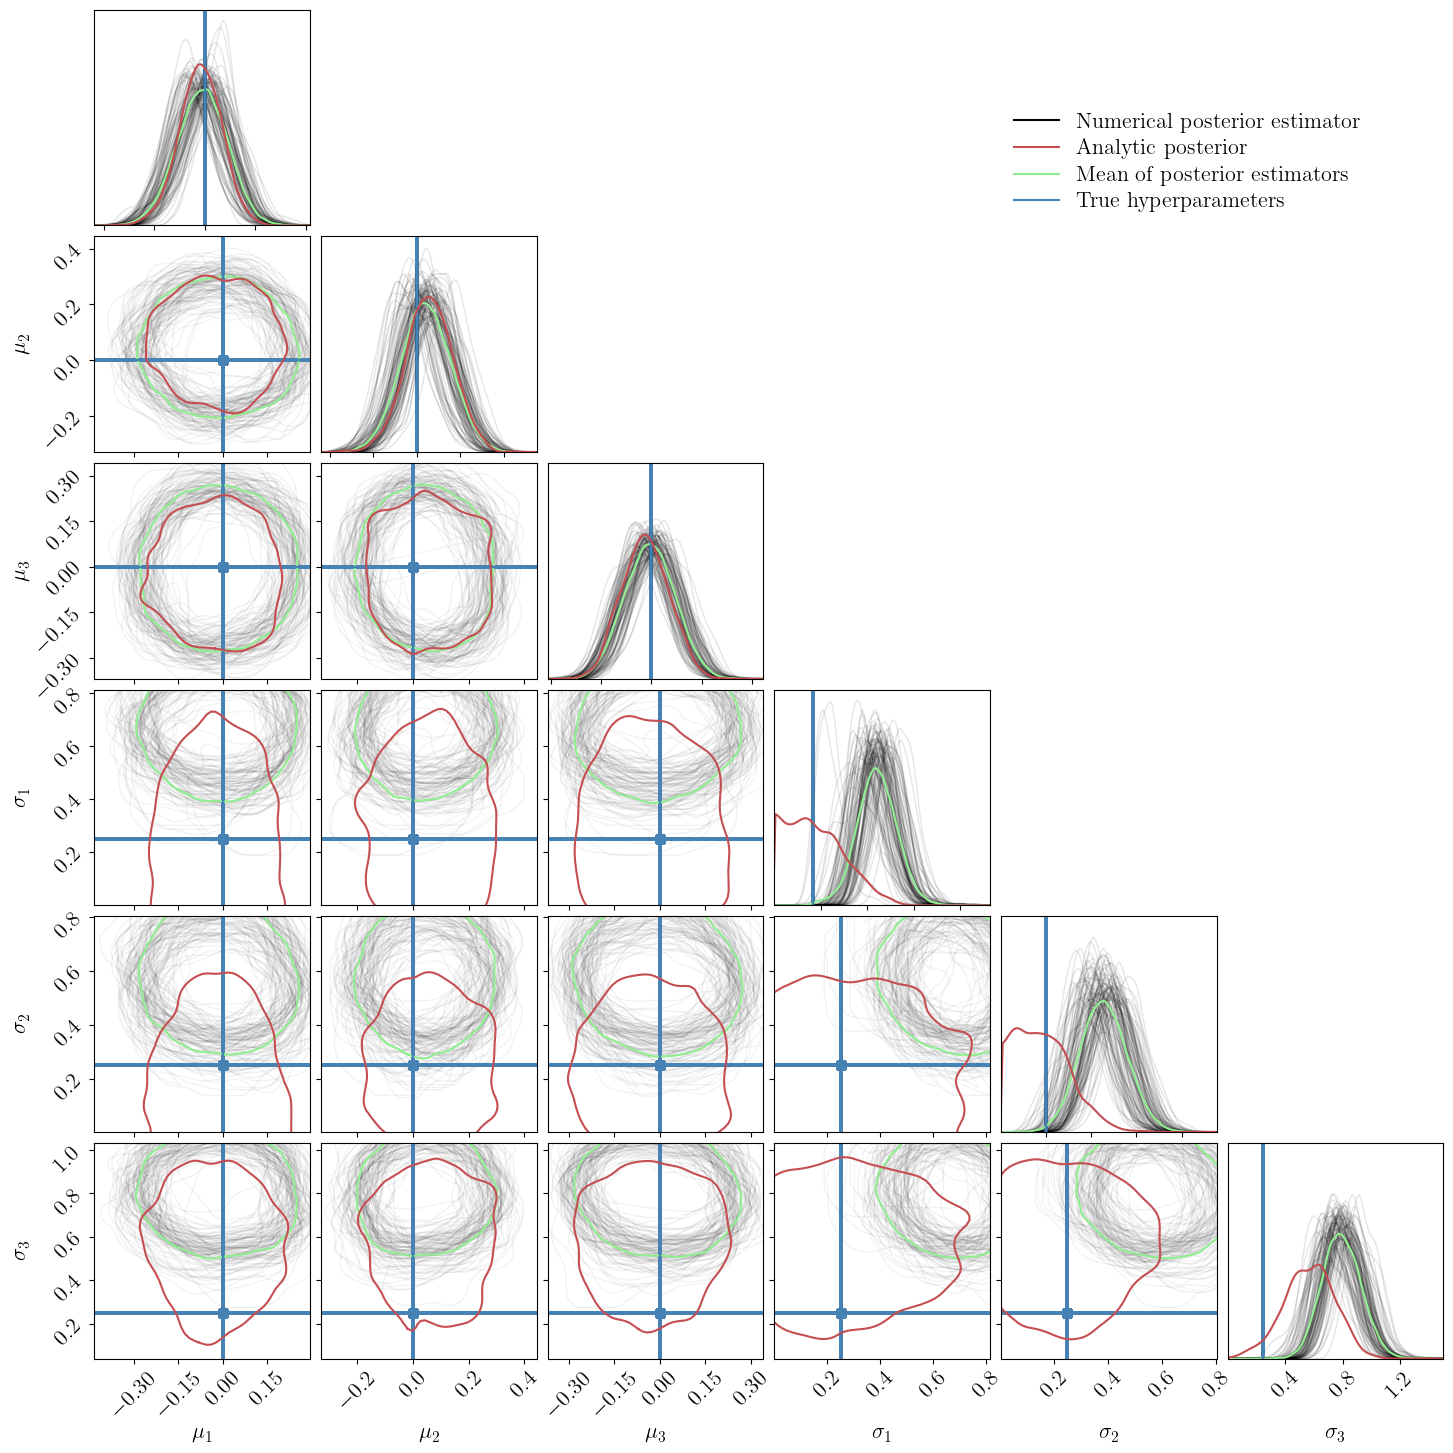

In [3]:
# from corner import corner
from pesummary.core.plots.corner import corner
from matplotlib.lines import Line2D
from scipy import stats
from pesummary.utils.bounded_2d_kde import Bounded_2d_kde
from pesummary.utils.bounded_1d_kde import bounded_1d_kde
# print(samples.shape)
labels = [f'$\mu_{{{ii+1}}}$' for ii in range(ndim)] + [f'$\sigma_{{{ii+1}}}$' for ii in range(ndim)]
truths = [true_mean] * ndim + [true_sd] * ndim

pad = 0.05

mins = np.minimum(np.min(analytical_samples, axis=0), np.min(numerical_hierarchical_posterior_samples, axis=(0,1)))
maxs = np.maximum(np.max(analytical_samples, axis=0), np.max(numerical_hierarchical_posterior_samples, axis=(0,1)))
range_ = np.array([
    mins - pad*np.abs(maxs - mins),
    maxs + pad*np.abs(maxs - mins)
]).T

minima = [-10] * ndim + [0.] * ndim
maxima = [10] * len(labels)

fig, axes = plt.subplots(nrows=len(labels), ncols=len(labels), figsize=(15,15))
for ii in tqdm(range(nrandom)):
#for ii in tqdm(range(5)):
    corner(
        numerical_hierarchical_posterior_samples[ii], labels, labels=labels, 
        color='k', smooth=5, range=range_, kde=bounded_1d_kde, kde_2d=Bounded_2d_kde, # kde=stats.gaussian_kde,
        bins=50, fig=fig, truths=truths, no_fill_contours=True, plot_density=False, 
        kde_kwargs={labels[ii]: {'xlow': minima[ii], "xhigh": maxima[ii]} for ii in range(len(labels))},
        kde_2d_kwargs={labels[ii]: {'low': minima[ii], "high": maxima[ii]} for ii in range(len(labels))},
        levels=[0.9], plot_datapoints=False, contour_kwargs={'alpha': 0.05, 'force_closed': True}, 
        marginal_kwargs={'color': 'k', 'alpha': 0.1, 'linewidth': 1}
    )
shape = numerical_hierarchical_posterior_samples.shape
corner(
    numerical_hierarchical_posterior_samples.reshape(shape[0]*shape[1], shape[2]), labels, 
    bins=50, fig=fig, smooth=1, range=range_, kde=bounded_1d_kde, kde_2d=Bounded_2d_kde, #kde=stats.gaussian_kde, #
    labels=labels, color='lightgreen', truths=truths, no_fill_contours=True, 
    kde_kwargs={labels[ii]: {'xlow': minima[ii], "xhigh": maxima[ii]} for ii in range(len(labels))},
    kde_2d_kwargs={labels[ii]: {'low': minima[ii], "high": maxima[ii]} for ii in range(len(labels))},
    plot_density=False, levels=[0.9], plot_datapoints=False, 
    marginal_kwargs={'color': 'lightgreen', 'alpha': 1}
)
corner(
    analytical_samples, labels, fig=fig, smooth=3, kde=bounded_1d_kde, kde_2d=Bounded_2d_kde, #kde=stats.gaussian_kde, #
    bins=50, labels=labels, color='r', range=range_, truths=truths, no_fill_contours=True, 
    kde_kwargs={labels[ii]: {'xlow': minima[ii], "xhigh": maxima[ii]} for ii in range(len(labels))},
    kde_2d_kwargs={labels[ii]: {'low': minima[ii], "high": maxima[ii]} for ii in range(len(labels))},
    plot_density=False, levels=[0.9], plot_datapoints=False,
    marginal_kwargs={'color': 'r', 'alpha': 1}
)

ylims = [5,5,5,5,5,5]

for ii in range(len(labels)):
    axes[ii,ii].set_ylim([0, ylims[ii]])
    xlo, xhi = axes[ii, ii].get_xlim()
    # print(xlo, xhi)
    axes[ii,ii].set_xlim([np.maximum(xlo, minima[ii]), np.minimum(xhi, maxima[ii])])

for ii in range(len(labels)):
    for jj in range(ii):

        xlo, xhi = axes[ii, jj].get_xlim()
        ylo, yhi = axes[ii, jj].get_ylim()
        axes[ii, jj].set_xlim([np.maximum(xlo, minima[jj]), np.minimum(xhi, maxima[jj])])
        axes[ii, jj].set_ylim([np.maximum(ylo, minima[ii]), np.minimum(yhi, maxima[ii])])

axes[0,len(labels)-2].legend(
    [Line2D([0,1], [0,1], color='k'), Line2D([0,1], [0,1], color='r'), Line2D([0,1], [0,1], color='lightgreen'), Line2D([0,1], [0,1], color='#4682b4')],
    ['Numerical posterior estimator', 'Analytic posterior', 'Mean of posterior estimators', 'True hyperparameters'], 
    frameon=False, loc='lower left', borderpad=0.1, labelspacing=0.3
)
plt.savefig(f'plots/{noise_dir}/Ndim{ndim}_Nobs{Nobs}_Npe{npe}_nrepeat{nrandom}.pdf')
plt.show()


In [38]:
a = {labels[ii]: {'xlow':0., "xhigh": 1} for ii in range(ndim,len(labels))}
a.get('$\sigma_{1}$')

{'xlow': 0.0, 'xhigh': 1}

In [34]:
minima

[-inf, -inf, -inf, -inf, -inf, -inf, 0, 0, 0, 0, 0, 0]

In [ ]:

kl_list = []
ckl_list = []
pest_list = []
cpest_list = []
panal_list = []

# npelist = np.logspace(1,3,60, dtype=int)
npelist = [10,100,1000,10_000]
for npe in npelist:
    PRNGkey, _ = jr.split(PRNGkey)

    if npe >= 500:
        big = True
    else:
        big = False
    # @jax.jit

    sigmas = jnp.linspace(-1,0.5,200)
    mus = jnp.full_like(sigmas, true_mean)
    dsigma = sigmas[1] - sigmas[0]

    def kl_and_ptrue(PRNGkey):

        log_posteriors, log_evidences, vs, wneff = random_posterior(PRNGkey, mus, sigmas, obs, npe, noise, dsigma, big=big)
        analytic_log_posterior, analytic_log_evidence = analytical_posterior(mus, sigmas, obs, noise, dsigma)

        KL_divs = [jnp.sum(jnp.exp(analytic_log_posterior) * (analytic_log_posterior - lp)) * dsigma / jnp.log(2) for lp in log_posteriors]

        return KL_divs, log_posteriors, analytic_log_posterior

    n_repeat = 100
    keys = jr.split(PRNGkey, n_repeat)
    # kl, p_est, p_anal = jax.lax.map(kl_and_ptrue, keys, batch_size=1)
    # eh, I'd rather have a tqdm progress bar lol
    kl, ckl, c2kl, pest, cpest, c2pest, apest = [], [], [], [], [], [], []
    klist = tqdm(keys)
    klist.set_description(f'N_PE = {npe}')
    for key in klist:
        k, p, pw = kl_and_ptrue(key)
        kl.append(k)
        pest.append(p)
        apest.append(pw)

    os.makedirs(f'diff_smaller_double_corrected_data/Ndim{ndim}_N{Nobs}_posteriors/', exist_ok=True)
    with open(f'diff_smaller_double_corrected_data/Ndim{ndim}_N{Nobs}_posteriors/npe_{npe}.pkl', 'wb') as ff:
        pkl.dump((np.array(kl), np.array(pest), np.array(pw), np.array(mus), np.array(sigmas)), ff)

## large noise